In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
X_train = np.load('data/X_train.npy')
X_test = np.load('data/X_test.npy')

y_train = np.load('data/y_train.npy')
y_test = np.load('data/y_test.npy')

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (29630, 41)
X_test shape: (7408, 41)
y_train shape: (29630,)
y_test shape: (7408,)


In [3]:
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

In [4]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)

LINEAR REGRESSION
MSE: 0.07538920267531436
RMSE: 0.2745709428823712
MAE: 0.20460913708531991
R2: 0.8701000206736427


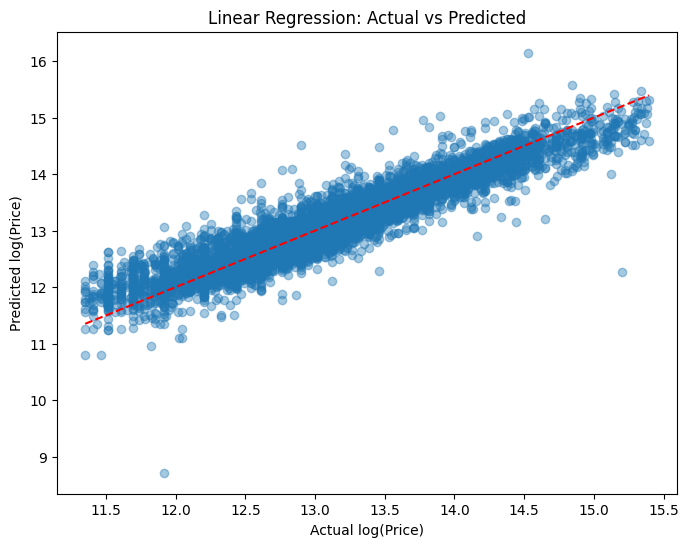

In [5]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')

plt.title('Linear Regression: Actual vs Predicted')

plt.savefig(
    'plots/linear_actual_vs_pred.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

In [6]:
joblib.dump(
    lr,
    'models/linear_regression.pkl'
)

['models/linear_regression.pkl']

In [7]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_r = ridge.predict(X_test)

mse_r = mean_squared_error(y_test, y_pred_r)
rmse_r = np.sqrt(mse_r)
mae_r = mean_absolute_error(y_test, y_pred_r)
r2_r = r2_score(y_test, y_pred_r)

print("RIDGE REGRESSION")
print("MSE:", mse_r)
print("RMSE:", rmse_r)
print("MAE:", mae_r)
print("R2:", r2_r)

RIDGE REGRESSION
MSE: 0.07538246234310789
RMSE: 0.2745586683080829
MAE: 0.20460105242269847
R2: 0.8701116346579163


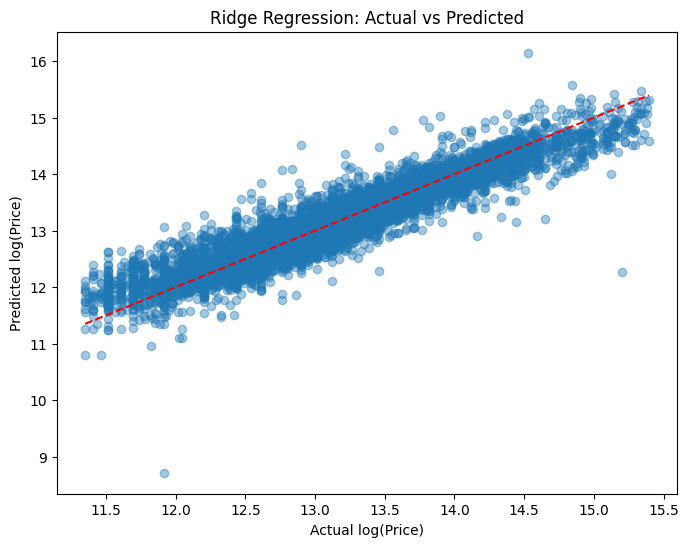

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_r, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')

plt.title('Ridge Regression: Actual vs Predicted')

plt.savefig(
    'plots/ridge_actual_vs_pred.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

In [9]:
joblib.dump(
    ridge,
    'models/ridge_regression.pkl'
)

['models/ridge_regression.pkl']

In [10]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

y_pred_l = lasso.predict(X_test)

mse_l = mean_squared_error(y_test, y_pred_l)
rmse_l = np.sqrt(mse_l)
mae_l = mean_absolute_error(y_test, y_pred_l)
r2_l = r2_score(y_test, y_pred_l)

print("LASSO REGRESSION")
print("MSE:", mse_l)
print("RMSE:", rmse_l)
print("MAE:", mae_l)
print("R2:", r2_l)

LASSO REGRESSION
MSE: 0.10325735133581866
RMSE: 0.3213368191412535
MAE: 0.24274576589517885
R2: 0.8220815802816642


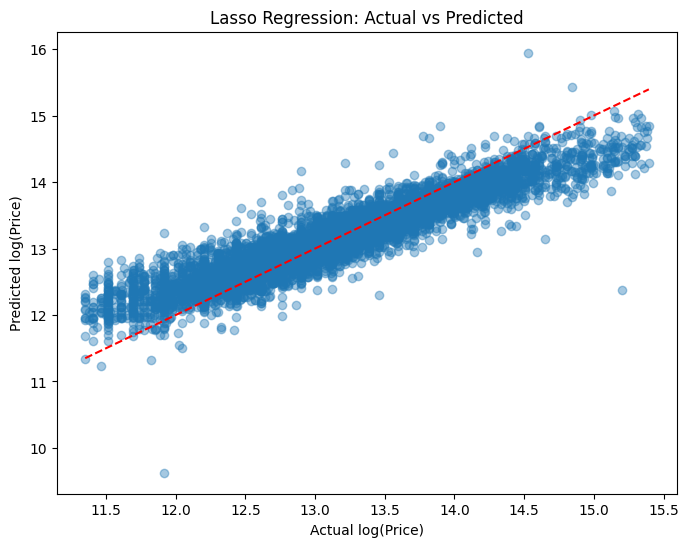

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_l, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')

plt.title('Lasso Regression: Actual vs Predicted')

plt.savefig(
    'plots/lasso_actual_vs_pred.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

In [12]:
joblib.dump(
    lasso,
    'models/lasso_regression.pkl'
)

['models/lasso_regression.pkl']

In [13]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

poly_model.fit(X_train, y_train)

y_pred_p = poly_model.predict(X_test)

mse_p = mean_squared_error(y_test, y_pred_p)
rmse_p = np.sqrt(mse_p)
mae_p = mean_absolute_error(y_test, y_pred_p)
r2_p = r2_score(y_test, y_pred_p)

print("POLYNOMIAL REGRESSION")
print("MSE:", mse_p)
print("RMSE:", rmse_p)
print("MAE:", mae_p)
print("R2:", r2_p)

POLYNOMIAL REGRESSION
MSE: 0.04364094045576425
RMSE: 0.20890414178700298
MAE: 0.14703608378961625
R2: 0.9248041223170699


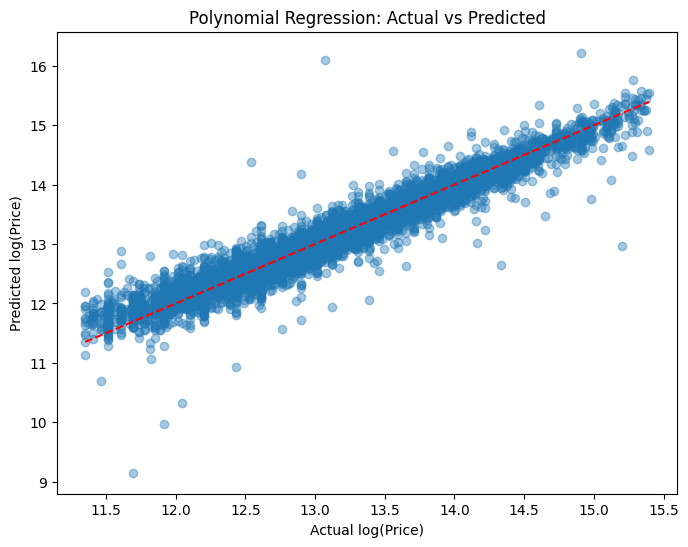

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_p, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')

plt.title('Polynomial Regression: Actual vs Predicted')

plt.savefig(
    'plots/poly_actual_vs_pred.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

In [15]:
joblib.dump(
    poly_model,
    'models/polynomial_regression.pkl'
)

['models/polynomial_regression.pkl']

In [16]:
svr = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1
)

svr.fit(
    X_train[:5000],
    y_train[:5000]
)

y_pred_s = svr.predict(X_test)

mse_s = mean_squared_error(y_test, y_pred_s)
rmse_s = np.sqrt(mse_s)
mae_s = mean_absolute_error(y_test, y_pred_s)
r2_s = r2_score(y_test, y_pred_s)

print("SVR")
print("MSE:", mse_s)
print("RMSE:", rmse_s)
print("MAE:", mae_s)
print("R2:", r2_s)

SVR
MSE: 0.04495412041614317
RMSE: 0.21202386756245903
MAE: 0.15053273828546138
R2: 0.9225414368972535


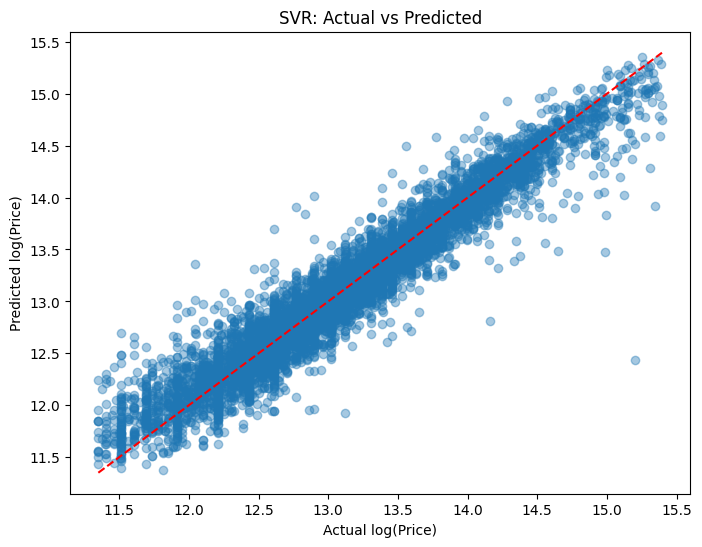

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_s, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')

plt.title('SVR: Actual vs Predicted')

plt.savefig(
    'plots/svr_actual_vs_pred.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()


In [18]:
joblib.dump(
    svr,
    'models/svr.pkl'
)

['models/svr.pkl']

In [19]:
metrics = {
    'Linear Regression': {
        'MSE': float(mse_lr),
        'RMSE': float(rmse_lr),
        'MAE': float(mae_lr),
        'R2': float(r2_lr)
    },

    'Ridge': {
        'MSE': float(mse_r),
        'RMSE': float(rmse_r),
        'MAE': float(mae_r),
        'R2': float(r2_r)
    },

    'Lasso': {
        'MSE': float(mse_l),
        'RMSE': float(rmse_l),
        'MAE': float(mae_l),
        'R2': float(r2_l)
    },

    'Polynomial': {
        'MSE': float(mse_p),
        'RMSE': float(rmse_p),
        'MAE': float(mae_p),
        'R2': float(r2_p)
    },

    'SVR': {
        'MSE': float(mse_s),
        'RMSE': float(rmse_s),
        'MAE': float(mae_s),
        'R2': float(r2_s)
    }
}

with open('regression_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("metrics saved")

metrics saved
